In [62]:
import pandas as pd

In [3]:
df = pd.read_csv("/home/dev/work_main/random/assesment/output/cv_scores_google_gemma-3-12b-it.csv")

In [4]:
df.head()

,document_name,Publication Record,Core Technical Specialization,Industry vs. Academic Research,Technical Skill Specificity,Research Experience Depth,Teaching Experience,Primary Research Domain,Project Impact Quantification,Work Experience Duration,...,Educational Stage and Focus,Mathematical Modeling Depth,Industry Internship Sophistication,Educational Background Detail,Research Role Progression,Research Project Scope,Research Output Visibility,Project Portfolio Visibility,Primary Development Environment,Technical Skills Listing
0,Peter-Michael Barkholz.txt,0,3,3,4,4,1,3,1,1,...,5,4,3,4,2,3,1,2,4,5
1,Loredana Neme#U0219.txt,1,3,2,4,2,0,3,1,1,...,4,2,3,3,2,4,4,2,3,5
2,Rudolf Baranka.txt,2,3,2,4,2,3,1,1,1,...,4,3,3,5,2,3,3,4,4,5
3,Lesia Mag#U00e1lov#U00e1.txt,1,3,4,4,3,2,4,3,2,...,4,2,3,4,1,3,3,4,3,5
4,Cord R#U00e4del.txt,2,3,2,4,3,4,3,1,1,...,3,2,3,2,3,3,4,1,3,4


In [56]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import argparse

# Default font sizes (easily adjustable)
DEFAULT_FONT_SIZES = {
    'title': 12,
    'axis_label': 14,
    'tick': 14,
    'bar_label': 10,
    'legend': 11,
    'suptitle': 16
}


# # Default font sizes (easily adjustable)
# DEFAULT_FONT_SIZES = {
#     'title': 14,
#     'axis_label': 12,
#     'tick': 11,
#     'bar_label': 10,
#     'legend': 11,
#     'suptitle': 16
# }

def load_categories(json_file: str) -> Tuple[List[str], List[int], List[str]]:
    """Load categories from JSON file."""
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Extract categories and counts
        categories = []
        counts = []
        questions = []
        
        for category, info in data.items():
            categories.append(category)
            counts.append(info['count'])
            questions.append(info['question'])
        
        return categories, counts, questions
    except Exception as e:
        print(f"Error loading {json_file}: {e}")
        return None, None, None

def get_top_n(categories: List[str], counts: List[int], questions: List[str], 
              n: int = 10) -> Tuple[List[str], List[int], List[str]]:
    """Get top N categories by count."""
    # Sort by count in descending order
    sorted_data = sorted(zip(categories, counts, questions), 
                        key=lambda x: x[1], reverse=True)
    
    # Get top N
    top_categories = [item[0] for item in sorted_data[:n]]
    top_counts = [item[1] for item in sorted_data[:n]]
    top_questions = [item[2] for item in sorted_data[:n]]
    
    return top_categories, top_counts, top_questions

def create_subplot(ax, categories: List[str], counts: List[int], 
                   questions: List[str], title: str, color: str = 'steelblue',
                   font_sizes: Dict = None, show_values: bool = True,
                   horizontal: bool = True, title_pad: float = 20.0):
    """
    Create a single subplot with categories.
    
    Args:
        ax: Matplotlib axis object
        categories: List of category names
        counts: List of category counts
        questions: List of evaluation questions
        title: Plot title
        color: Bar color
        font_sizes: Dictionary of font sizes
        show_values: Whether to show count values on bars
        horizontal: Whether to use horizontal bars
        title_pad: Padding below the title (in points)
    """
    if font_sizes is None:
        font_sizes = DEFAULT_FONT_SIZES
    
    if horizontal:
        # Create horizontal bar chart
        y_pos = np.arange(len(categories))
        bars = ax.barh(y_pos, counts, color=color, alpha=0.8, height=0.7)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(categories, fontsize=font_sizes['tick'])
        ax.invert_yaxis()  # Highest count at top
        ax.set_xlabel('Frequency Count', fontsize=font_sizes['axis_label'])
        
        # Add count labels on bars
        if show_values:
            for i, (bar, count) in enumerate(zip(bars, counts)):
                width = bar.get_width()
                ax.text(width + max(counts) * 0.01, 
                       bar.get_y() + bar.get_height()/2,
                       f'{count}', 
                       ha='left', va='center', 
                       fontsize=font_sizes['bar_label'],
                       fontweight='bold')
        
        # Set x-axis limit
        ax.set_xlim(0, max(counts) * 1.15)
    else:
        # Create vertical bar chart
        x_pos = np.arange(len(categories))
        bars = ax.bar(x_pos, counts, color=color, alpha=0.8, width=0.7)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(categories, rotation=45, ha='right', 
                          fontsize=font_sizes['tick'])
        ax.set_ylabel('Frequency Count', fontsize=font_sizes['axis_label'])
        
        # Add count labels on bars
        if show_values:
            for bar, count in zip(bars, counts):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., 
                       height + max(counts) * 0.01,
                       f'{count}', 
                       ha='center', va='bottom', 
                       fontsize=font_sizes['bar_label'],
                       fontweight='bold')
        
        # Set y-axis limit
        ax.set_ylim(0, max(counts) * 1.15)
    
    # Set title with increased padding for better spacing
    ax.set_title(title, fontsize=font_sizes['title'], fontweight='bold', pad=title_pad)
    
    # Add grid for better readability
    ax.grid(axis='x' if horizontal else 'y', alpha=0.3, linestyle='--')
    
    # Adjust top margin to prevent title overlap
    ax.margins(y=0.1)  # Add 10% margin at top
    
    return bars

def plot_top_categories(json_files: List[str], category_names: List[str], model_name: str,
                        figsize: Tuple[int, int] = (18, 8),
                        font_sizes: Dict = None,
                        horizontal: bool = True,
                        output_file: str = None,
                        n_categories: int = 10,
                        title_pad: float = 25.0) -> Tuple[plt.Figure, List, List]:
    """
    Plot top categories from multiple JSON files in subplots.
    
    Args:
        json_files: List of JSON file paths
        category_names: List of category/rubric names for titles
        model_name: Name of the model for overall title
        figsize: Figure size (width, height)
        font_sizes: Dictionary of font sizes for different elements
        horizontal: Whether to use horizontal bars (True) or vertical (False)
        output_file: Path to save the figure (optional)
        n_categories: Number of top categories to show
        title_pad: Padding below each subplot title (in points)
    
    Returns:
        fig, axes: Matplotlib figure and axes objects
        all_data: List of dictionaries with plot data
    """
    if font_sizes is None:
        font_sizes = DEFAULT_FONT_SIZES
    
    n_plots = len(json_files)
    if n_plots != len(category_names):
        raise ValueError(f"Number of JSON files ({n_plots}) must match number of category names ({len(category_names)})")
    
    # Set up the figure with subplots
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, 
                             constrained_layout=True if n_plots > 1 else False)
    
    if n_plots == 1:
        axes = [axes]  # Make it iterable
    
    # Colors for different subplots
    colors = plt.cm.Set3(np.linspace(0, 1, n_plots))
    
    # Process each JSON file
    all_data = []
    for i, (json_file, category_name) in enumerate(zip(json_files, category_names)):
        categories, counts, questions = load_categories(json_file)
        if categories is None:
            print(f"Skipping {json_file} due to loading error")
            continue
        
        # Get top N categories
        top_categories, top_counts, top_questions = get_top_n(
            categories, counts, questions, n=n_categories
        )
        
        # Store data for summary
        all_data.append({
            'category': category_name,
            'categories': top_categories,
            'counts': top_counts,
            'questions': top_questions
        })
        
        # Create subplot with category/rubric name in title
        title = f"{category_name}"
        create_subplot(axes[i], top_categories, top_counts, top_questions, 
                       title, color=colors[i], 
                       font_sizes=font_sizes, horizontal=horizontal,
                       title_pad=title_pad)
    
    # Add overall title with model name
    if n_plots > 1:
        fig.suptitle(f'{model_name}: Top {n_categories} Categories Comparison', 
                     fontsize=font_sizes['suptitle'], 
                     fontweight='bold', y=1.05)  # Changed from y=1.02 to y=1.05
    else:
        # For single plot, add model name to the axis title
        axes[0].set_title(f'{model_name}: {category_names[0]}', 
                          fontsize=font_sizes['title'] + 2, fontweight='bold', pad=title_pad)
    
    # Add extra spacing between suptitle and subplots
    if n_plots > 1:
        plt.subplots_adjust(top=0.85)  # Add this line to create more space at the top
    
    if not output_file and n_plots == 1:
        output_file = f"{model_name.replace(' ', '_').lower()}_{category_names[0].replace(' ', '_').lower()}_top{n_categories}.png"
    elif not output_file:
        output_file = f"{model_name.replace(' ', '_').lower()}_comparison_top{n_categories}.png"
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {output_file}")
    
    return fig, axes, all_data

def plot_single_model(json_file: str, category_name: str, model_name: str,
                     figsize: Tuple[int, int] = (12, 8),
                     font_sizes: Dict = None,
                     horizontal: bool = True,
                     n_categories: int = 10,
                     output_file: str = None,
                     title_pad: float = 50.0) -> Tuple[plt.Figure, plt.Axes, Dict]:
    """
    Plot top categories for a single model.
    
    Args:
        json_file: JSON file path
        category_name: Category/rubric name
        model_name: Name of the model
        figsize: Figure size (width, height)
        font_sizes: Dictionary of font sizes for different elements
        horizontal: Whether to use horizontal bars (True) or vertical (False)
        n_categories: Number of top categories to show
        output_file: Path to save the figure (optional)
        title_pad: Padding below the title (in points)
    
    Returns:
        fig, ax: Matplotlib figure and axis objects
        plot_data: Dictionary with plot data
    """
    if font_sizes is None:
        font_sizes = DEFAULT_FONT_SIZES
    
    # Load data
    categories, counts, questions = load_categories(json_file)
    if categories is None:
        raise ValueError(f"Failed to load data from {json_file}")
    
    # Get top N categories
    top_categories, top_counts, top_questions = get_top_n(
        categories, counts, questions, n=n_categories
    )
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create plot with model name and category name in title
    title = f"{model_name}: {category_name}"
    create_subplot(ax, top_categories, top_counts, top_questions, 
                  title, color='steelblue', 
                  font_sizes=font_sizes, horizontal=horizontal,
                  title_pad=title_pad)
    
    # Store data
    plot_data = {
        'model': model_name,
        'category': category_name,
        'categories': top_categories,
        'counts': top_counts,
        'questions': top_questions
    }
    
    if not output_file:
        output_file = f"{model_name.replace(' ', '_').lower()}_{category_name.replace(' ', '_').lower()}_top{n_categories}.png"
    
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {output_file}")
    
    return fig, ax, plot_data

def plot_flexible_grid(json_files: List[str], category_names: List[str], model_name: str,
                       figsize: Tuple[int, int] = (20, 12),
                       font_sizes: Dict = None,
                       horizontal: bool = True,
                       output_file: str = None,
                       n_categories: int = 10,
                       title_pad: float = 50.0) -> Tuple[plt.Figure, List, List]:
    """
    Plot top categories from multiple JSON files in a flexible grid layout.
    Supports 1-4 categories with optimal grid arrangement.
    
    Args:
        json_files: List of JSON file paths (1-4)
        category_names: List of category/rubric names for titles
        model_name: Name of the model for overall title
        figsize: Figure size (width, height)
        font_sizes: Dictionary of font sizes for different elements
        horizontal: Whether to use horizontal bars (True) or vertical (False)
        output_file: Path to save the figure (optional)
        n_categories: Number of top categories to show
        title_pad: Padding below each subplot title (in points)
    
    Returns:
        fig, axes: Matplotlib figure and axes objects
        all_data: List of dictionaries with plot data
    """
    if font_sizes is None:
        font_sizes = DEFAULT_FONT_SIZES
    
    n_cats = len(json_files)
    if n_cats != len(category_names):
        raise ValueError(f"Number of JSON files ({n_cats}) must match number of category names ({len(category_names)})")
    
    if n_cats > 4:
        raise ValueError("This function supports up to 4 categories. For more categories, use plot_multi_grid.")
    
    # Determine grid layout based on number of categories
    if n_cats == 1:
        n_rows, n_cols = 1, 1
        figsize = (figsize[0] // 2, figsize[1])  # Smaller for single plot
    elif n_cats == 2:
        n_rows, n_cols = 1, 2
    elif n_cats == 3:
        n_rows, n_cols = 2, 2  # Leave one empty
    else:  # n_cats == 4
        n_rows, n_cols = 2, 2
    
    # Set up the figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, 
                             constrained_layout=True)
    
    # Flatten axes array for easier indexing
    if n_cats == 1:
        axes = np.array([[axes]])
    elif n_cats <= 2:
        axes = axes.reshape(1, -1)
    
    # Colors for different categories
    colors = plt.cm.Set3(np.linspace(0, 1, n_cats))
    
    # Process each JSON file
    all_data = []
    for i, (json_file, category_name) in enumerate(zip(json_files, category_names)):
        categories, counts, questions = load_categories(json_file)
        if categories is None:
            print(f"Skipping {json_file} due to loading error")
            continue
        
        # Get top N categories
        top_categories, top_counts, top_questions = get_top_n(
            categories, counts, questions, n=n_categories
        )
        
        # Store data for summary
        all_data.append({
            'category': category_name,
            'categories': top_categories,
            'counts': top_counts,
            'questions': top_questions
        })
        
        # Determine subplot position
        if n_cats == 3 and i == 2:
            # For 3 categories, place the third one in position (1, 1)
            row, col = 1, 0
        else:
            row = i // n_cols
            col = i % n_cols
        
        # Create subplot with category name in title
        title = f"{category_name}"
        create_subplot(axes[row, col], top_categories, top_counts, top_questions, 
                       title, color=colors[i], 
                       font_sizes=font_sizes, horizontal=horizontal,
                       title_pad=title_pad)  # Added title_pad parameter
    
    # Hide empty subplots (for 3 categories case)
    if n_cats == 3:
        axes[1, 1].axis('off')
    
    fig.suptitle(f'{model_name}: Top {n_categories} Categories Comparison', 
                 fontsize=font_sizes['suptitle'], 
                 fontweight='bold', y=1.02)  # Added y parameter for better positioning
    
    # Add extra spacing between suptitle and subplots
    plt.subplots_adjust(top=0.88)  # Add this line to create more space at the top
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {output_file}")
    
    return fig, axes, all_data

def print_summary(all_data: List[Dict], model_name: str = "", font_sizes: Dict = None):
    """Print summary statistics for the plotted data."""
    if font_sizes is None:
        font_sizes = DEFAULT_FONT_SIZES
    
    print("\n" + "="*80)
    if model_name:
        print(f"SUMMARY STATISTICS - {model_name}")
    else:
        print("SUMMARY STATISTICS")
    print("="*80)
    
    for data in all_data:
        print(f"\n{data['category']}:")
        print("-" * 40)
        
        total_count = sum(data['counts'])
        avg_count = total_count / len(data['counts'])
        
        print(f"Total count for top {len(data['counts'])} categories: {total_count}")
        print(f"Average count per category: {avg_count:.1f}")
        print(f"Top category: {data['categories'][0]} ({data['counts'][0]} occurrences)")
        
        # Print top categories
    
    
        print(f"\nTop {min(5, len(data['categories']))} categories:")
        for j in range(min(5, len(data['categories']))):
            percentage = (data['counts'][j] / total_count) * 100
            print(f"  {j+1}. {data['categories'][j]}: {data['counts'][j]} ({percentage:.1f}%)")

/tmp/ipykernel_771066/1097262159.py:226: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.85)  # Add this line to create more space at the top


Figure saved to: deepseek_v3_comparison_top10.png


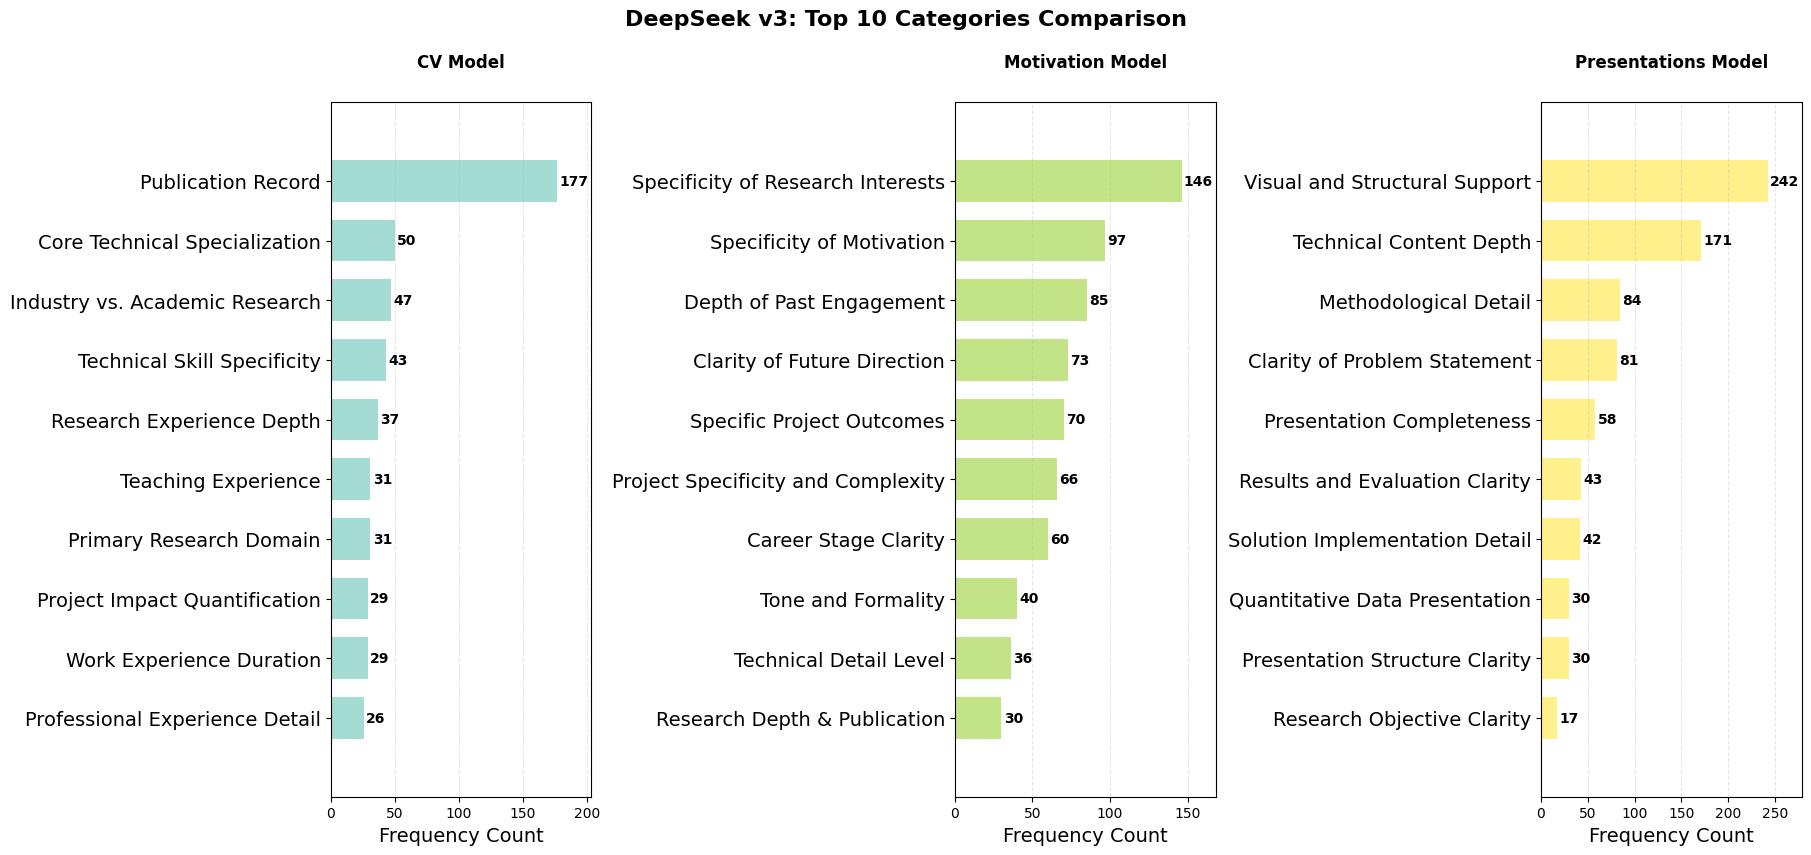


SUMMARY STATISTICS

CV Model:
----------------------------------------
Total count for top 10 categories: 500
Average count per category: 50.0
Top category: Publication Record (177 occurrences)

Top 5 categories:
  1. Publication Record: 177 (35.4%)
  2. Core Technical Specialization: 50 (10.0%)
  3. Industry vs. Academic Research: 47 (9.4%)
  4. Technical Skill Specificity: 43 (8.6%)
  5. Research Experience Depth: 37 (7.4%)

Motivation Model:
----------------------------------------
Total count for top 10 categories: 703
Average count per category: 70.3
Top category: Specificity of Research Interests (146 occurrences)

Top 5 categories:
  1. Specificity of Research Interests: 146 (20.8%)
  2. Specificity of Motivation: 97 (13.8%)
  3. Depth of Past Engagement: 85 (12.1%)
  4. Clarity of Future Direction: 73 (10.4%)
  5. Specific Project Outcomes: 70 (10.0%)

Presentations Model:
----------------------------------------
Total count for top 10 categories: 798
Average count per categor

In [57]:
json_files = [
    'cat_mining_results/deep_seek_v3/cv_categories.json',
    'cat_mining_results/deep_seek_v3/motivation_categories.json', 
    'cat_mining_results/deep_seek_v3/presentations_categories.json'
]
category_names = ['CV Model', 'Motivation Model', 'Presentations Model']

fig, axes, data = plot_top_categories(json_files, category_names, model_name='DeepSeek v3')
plt.show()
print_summary(data)

/tmp/ipykernel_771066/1097262159.py:226: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.85)  # Add this line to create more space at the top


Figure saved to: gemma_3_12b_comparison_top10.png


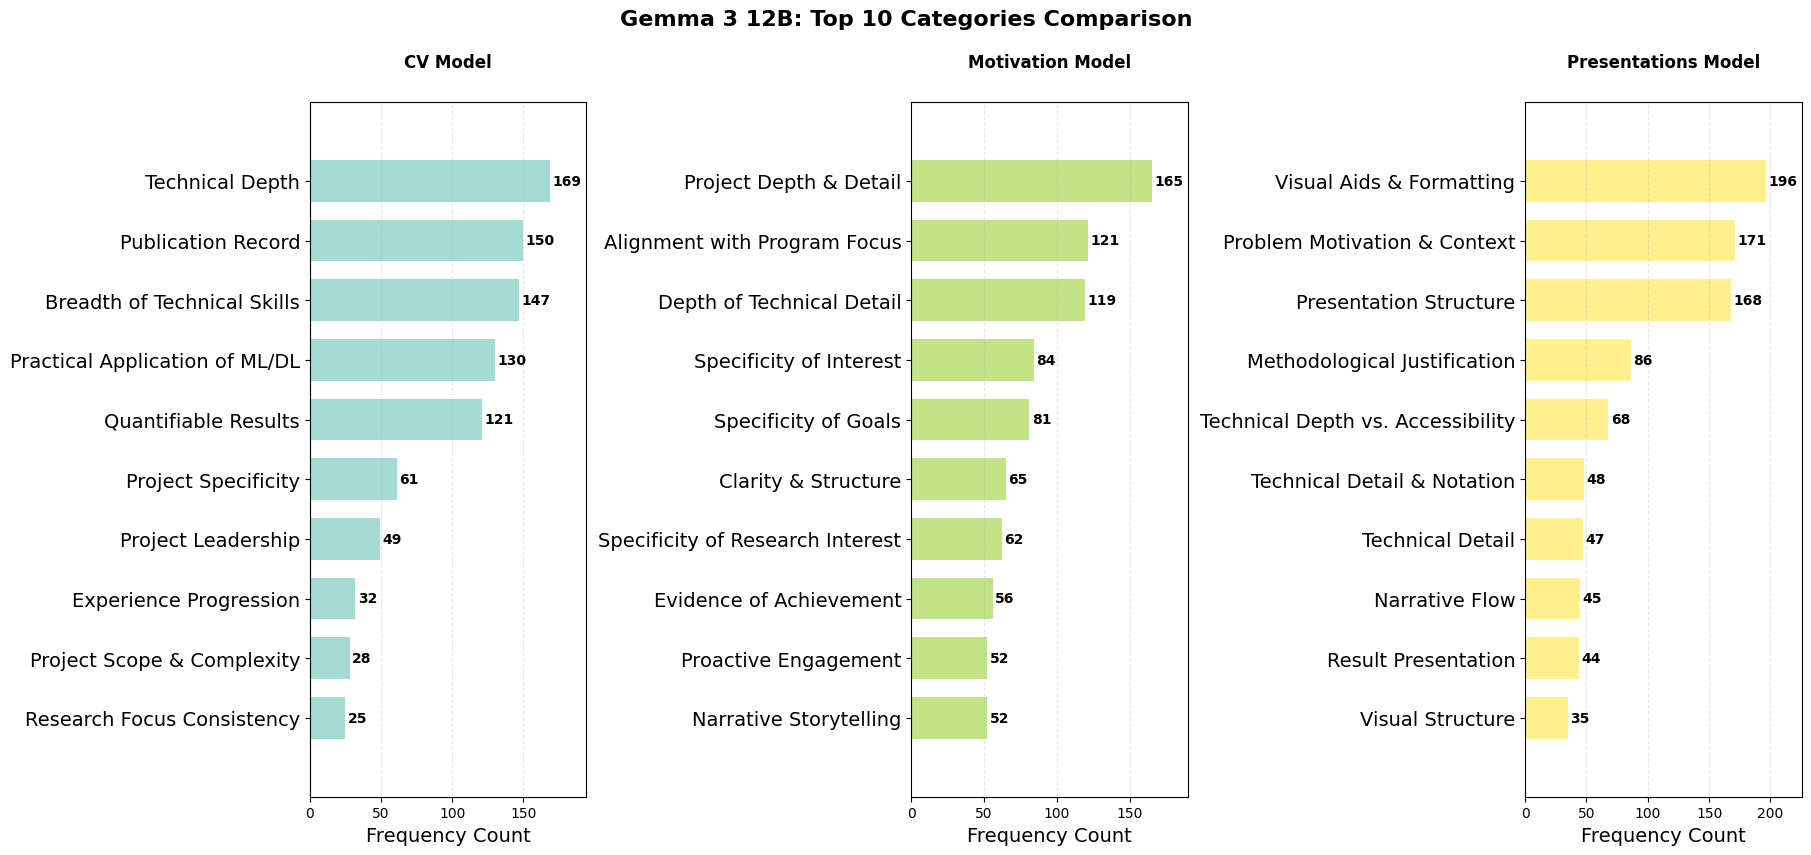


SUMMARY STATISTICS

CV Model:
----------------------------------------
Total count for top 10 categories: 912
Average count per category: 91.2
Top category: Technical Depth (169 occurrences)

Top 5 categories:
  1. Technical Depth: 169 (18.5%)
  2. Publication Record: 150 (16.4%)
  3. Breadth of Technical Skills: 147 (16.1%)
  4. Practical Application of ML/DL: 130 (14.3%)
  5. Quantifiable Results: 121 (13.3%)

Motivation Model:
----------------------------------------
Total count for top 10 categories: 857
Average count per category: 85.7
Top category: Project Depth & Detail (165 occurrences)

Top 5 categories:
  1. Project Depth & Detail: 165 (19.3%)
  2. Alignment with Program Focus: 121 (14.1%)
  3. Depth of Technical Detail: 119 (13.9%)
  4. Specificity of Interest: 84 (9.8%)
  5. Specificity of Goals: 81 (9.5%)

Presentations Model:
----------------------------------------
Total count for top 10 categories: 908
Average count per category: 90.8
Top category: Visual Aids & Format

In [58]:
json_files = [
    '/home/dev/work_main/random/assesment/cat_mining_results/gemma3_12B/cv_categories_gemma3_12B.json',
    '/home/dev/work_main/random/assesment/cat_mining_results/gemma3_12B/motivation_categories_gemma3_12_B.json', 
    '/home/dev/work_main/random/assesment/cat_mining_results/gemma3_12B/presentations_categories_gemma-3-12b-it.json'
]
model_names = ['CV Model', 'Motivation Model', 'Presentations Model']

fig, axes, data = plot_top_categories(json_files, category_names, model_name='Gemma 3 12B')
plt.show()
print_summary(data)

/tmp/ipykernel_771066/1097262159.py:226: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.85)  # Add this line to create more space at the top


Figure saved to: llama3_8b_comparison_top10.png


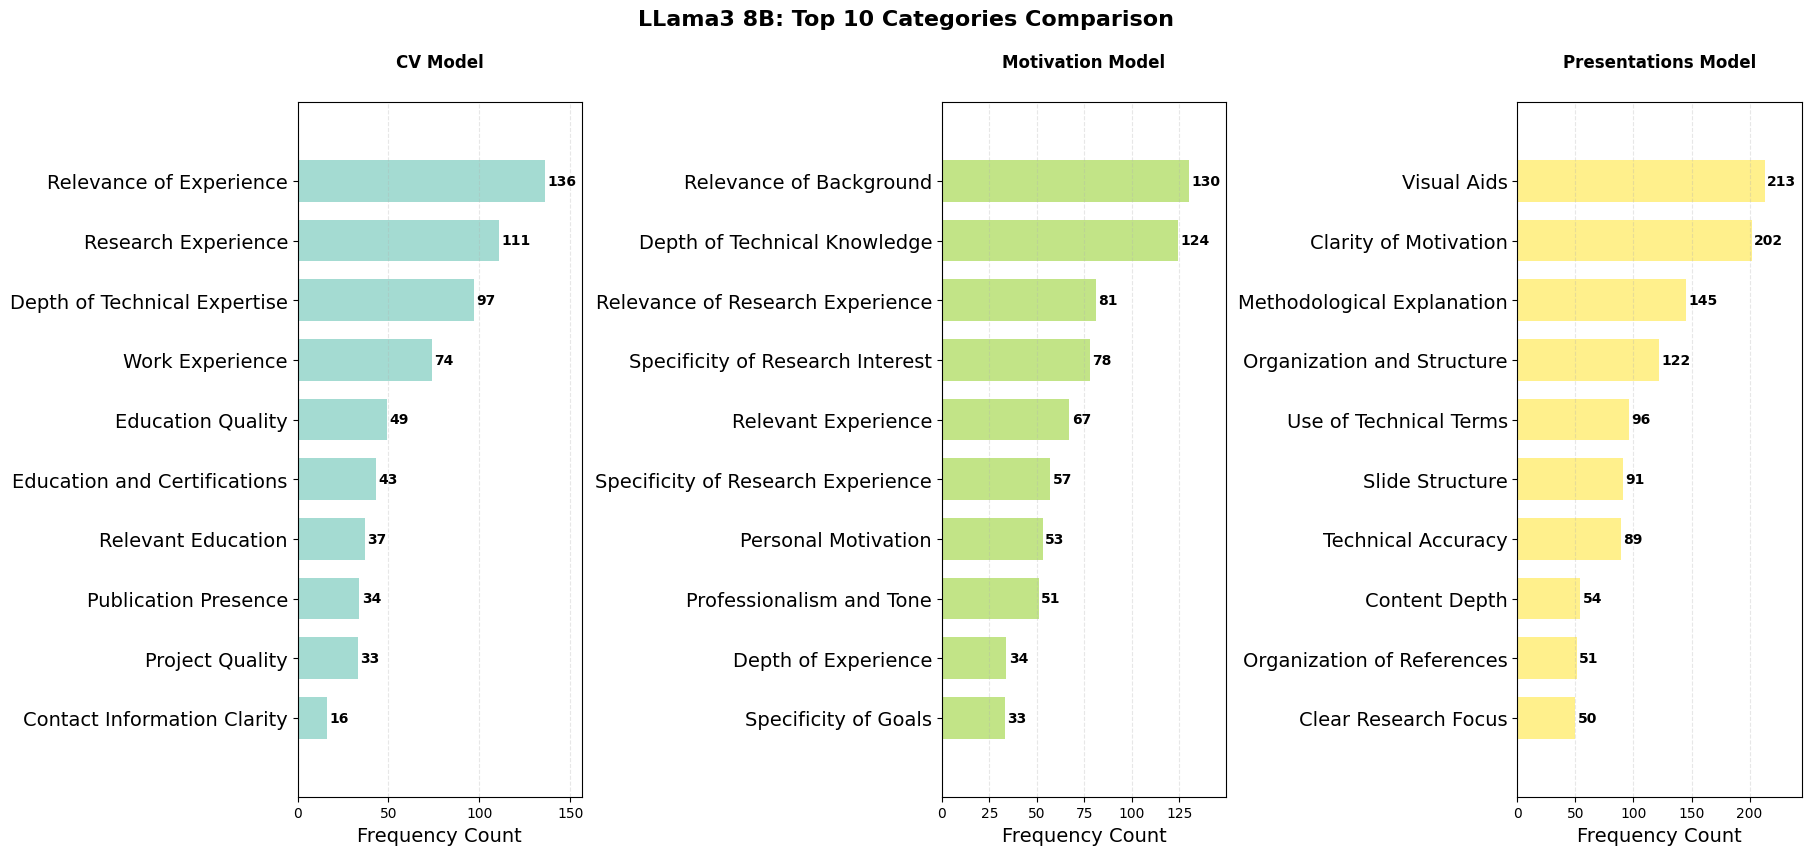


SUMMARY STATISTICS

CV Model:
----------------------------------------
Total count for top 10 categories: 630
Average count per category: 63.0
Top category: Relevance of Experience (136 occurrences)

Top 5 categories:
  1. Relevance of Experience: 136 (21.6%)
  2. Research Experience: 111 (17.6%)
  3. Depth of Technical Expertise: 97 (15.4%)
  4. Work Experience: 74 (11.7%)
  5. Education Quality: 49 (7.8%)

Motivation Model:
----------------------------------------
Total count for top 10 categories: 708
Average count per category: 70.8
Top category: Relevance of Background (130 occurrences)

Top 5 categories:
  1. Relevance of Background: 130 (18.4%)
  2. Depth of Technical Knowledge: 124 (17.5%)
  3. Relevance of Research Experience: 81 (11.4%)
  4. Specificity of Research Interest: 78 (11.0%)
  5. Relevant Experience: 67 (9.5%)

Presentations Model:
----------------------------------------
Total count for top 10 categories: 1113
Average count per category: 111.3
Top category: Visua

In [59]:
json_files = [
   "/home/dev/work_main/random/assesment/cat_mining_results/llama3_12B/cv_categories_llama3_instruct.json",
   '/home/dev/work_main/random/assesment/cat_mining_results/llama3_12B/motivation_categories_llama3_instruct.json', 
    '/home/dev/work_main/random/assesment/cat_mining_results/llama3_12B/presentations_categories_llama3_instruct.json'
]
model_names = ['CV Model', 'Motivation Model', 'Presentations Model']

fig, axes, data = plot_top_categories(json_files, category_names, model_name='LLama3 8B')
plt.show()
print_summary(data)

/tmp/ipykernel_771066/1097262159.py:226: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.85)  # Add this line to create more space at the top


Figure saved to: mistral_7b_comparison_top10.png


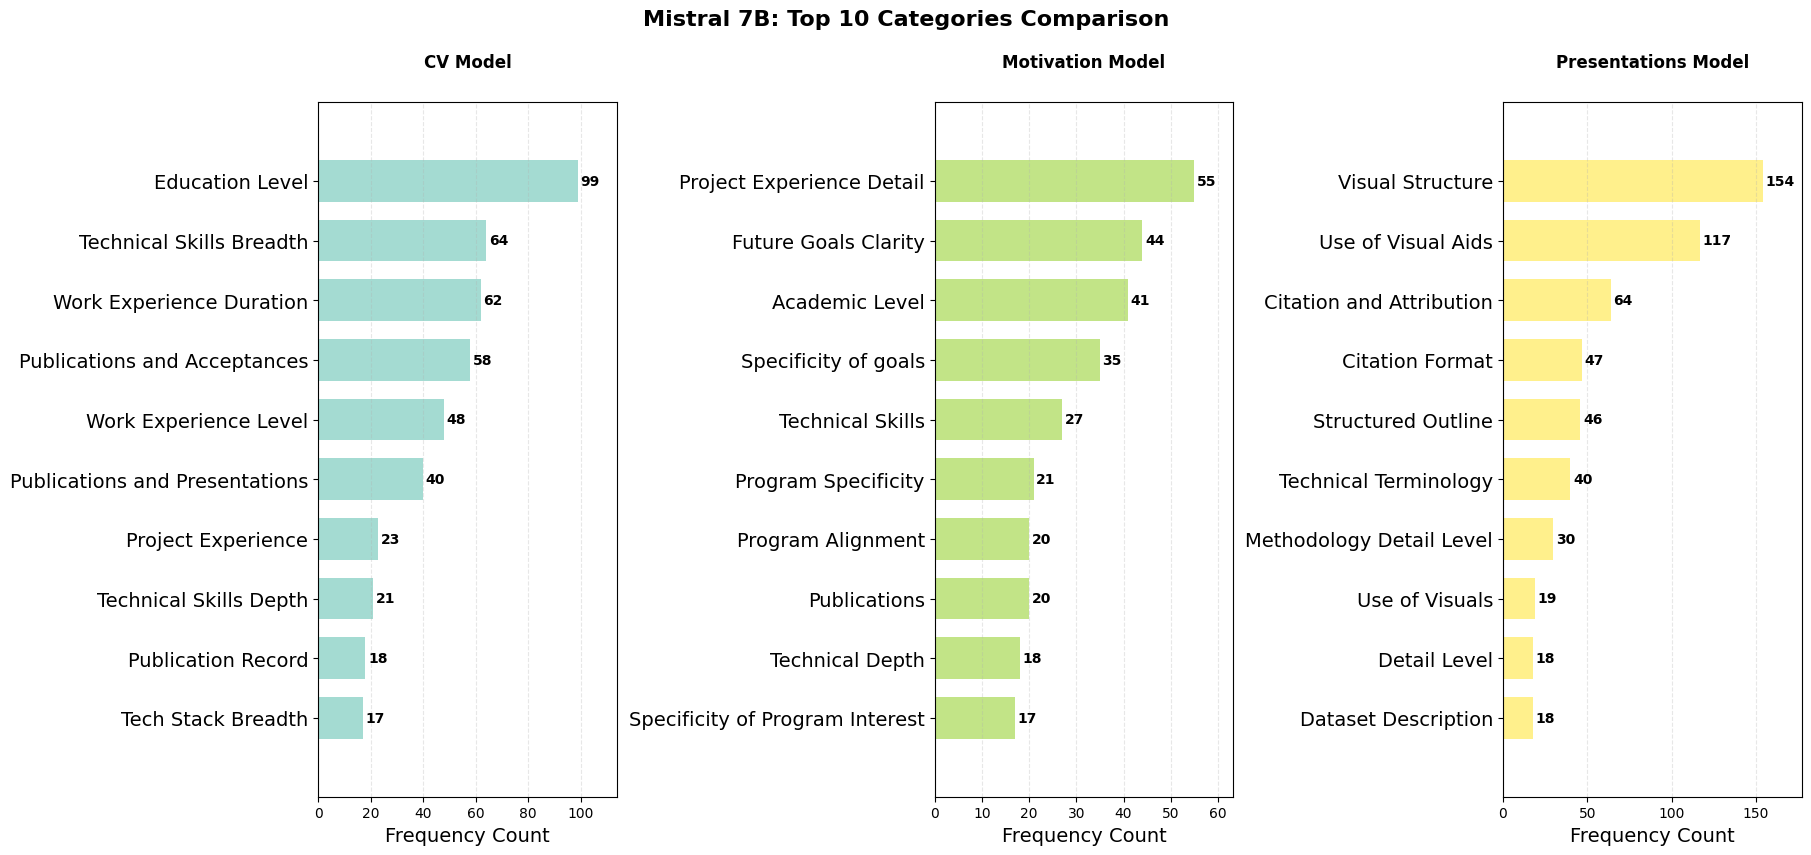


SUMMARY STATISTICS

CV Model:
----------------------------------------
Total count for top 10 categories: 450
Average count per category: 45.0
Top category: Education Level (99 occurrences)

Top 5 categories:
  1. Education Level: 99 (22.0%)
  2. Technical Skills Breadth: 64 (14.2%)
  3. Work Experience Duration: 62 (13.8%)
  4. Publications and Acceptances: 58 (12.9%)
  5. Work Experience Level: 48 (10.7%)

Motivation Model:
----------------------------------------
Total count for top 10 categories: 298
Average count per category: 29.8
Top category: Project Experience Detail (55 occurrences)

Top 5 categories:
  1. Project Experience Detail: 55 (18.5%)
  2. Future Goals Clarity: 44 (14.8%)
  3. Academic Level: 41 (13.8%)
  4. Specificity of goals: 35 (11.7%)
  5. Technical Skills: 27 (9.1%)

Presentations Model:
----------------------------------------
Total count for top 10 categories: 553
Average count per category: 55.3
Top category: Visual Structure (154 occurrences)

Top 5 categ

In [60]:
json_files = [
   "/home/dev/work_main/random/assesment/cat_mining_results/mistral_7b/cv_categories_mistrtal7b.json",
   '/home/dev/work_main/random/assesment/cat_mining_results/mistral_7b/motivation_categories_mistrtal7b.json', 
    '/home/dev/work_main/random/assesment/cat_mining_results/mistral_7b/presentations_categories_mistrtal7b.json'
]
model_names = ['CV Model', 'Motivation Model', 'Presentations Model']

fig, axes, data = plot_top_categories(json_files, category_names, model_name='Mistral 7B')
plt.show()
print_summary(data)

In [63]:
human_scores = pd.read_parquet("./data/dataset.parquet")
human_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 581 entries, Adam Mazilescu to Ștefania Albu
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cv                          571 non-null    object 
 1   letter                      572 non-null    object 
 2   presentation                568 non-null    object 
 3   cv_phd_1                    571 non-null    float64
 4   cv_phd_2                    571 non-null    float64
 5   letter_phd_1                571 non-null    float64
 6   letter_phd_2                571 non-null    float64
 7   pres_phd_1                  571 non-null    float64
 8   pres_phd_2                  571 non-null    float64
 9   pres_class                  571 non-null    float64
 10  video_phd_1                 387 non-null    float64
 11  video_phd_2                 413 non-null    float64
 12  all_phd_1                   571 non-null    float64
 13  all_phd_2        

In [69]:
human_scores['school_participation_flag'], human_scores['project_participation_flag']

(name
 Adam Mazilescu     True
 Adam Wieloch       True
 Adi Cristea        True
 Adolf Spieß .      True
 Adrián Labuda      True
                   ...  
 Ľudovít Čapka      True
 Žofia Krajčová     True
 Žofia Sameľová    False
 Șerban Tomescu    False
 Ștefania Albu      True
 Name: school_participation_flag, Length: 581, dtype: bool,
 name
 Adam Mazilescu     True
 Adam Wieloch      False
 Adi Cristea        True
 Adolf Spieß .     False
 Adrián Labuda     False
                   ...  
 Ľudovít Čapka     False
 Žofia Krajčová    False
 Žofia Sameľová    False
 Șerban Tomescu    False
 Ștefania Albu     False
 Name: project_participation_flag, Length: 581, dtype: bool)

In [79]:
import pandas as pd

# Define paths
csv_files = ["/home/dev/work_main/random/assesment/all_criteria_scored/mistral_nemo/cv_scores_mistralai_mistral-nemo.csv",
             "/home/dev/work_main/random/assesment/all_criteria_scored/mistral_nemo/motivation_scores_mistralai_mistral-nemo.csv",
             "/home/dev/work_main/random/assesment/all_criteria_scored/mistral_nemo/presentation_scores_mistralai_mistral-nemo.csv"]
parquet_path = "./data/dataset.parquet"


def clean_name(name):
    """Improved cleaning for document names."""
    if pd.isna(name):
        return name
    
    name = str(name)
    
    # Remove .txt extension
    name = name.replace('.txt', '')
    
    # Remove hyphens
    name = name.replace('-', '')
    
    # Decode Unicode escape sequences like #U0161
    def decode_unicode(match):
        hex_code = match.group(1)
        try:
            return chr(int(hex_code, 16))
        except:
            return match.group(0)
    
    name = re.sub(r'#U([0-9a-fA-F]{4})', decode_unicode, name)
    
    # Remove trailing dots and spaces
    name = name.strip('. ')
    
    return name

def is_valid_document_name(name):
    """Check if name looks like a real document name (not a metadata file)."""
    if pd.isna(name):
        return False
    
    name = str(name).lower()
    
    # Exclude obvious file names/metadata
    exclude_patterns = [
        'prof_eval_anon',
        'anonymized_test_project_scores_final',
        'offline_tests',
        'anon_projects_scores',
        '.xls',
        '.cs',
        '.csv',
        'test_',
        'eval_',
        'anon_',
        'score',
        'project_scores'
    ]
    
    for pattern in exclude_patterns:
        if pattern in name:
            return False
    
    # Should contain at least one letter and look like a person's name
    if not re.search(r'[a-z]', name):
        return False
    
    return True


# Read parquet and select specific columns
scores = pd.read_parquet(parquet_path)[['school_participation_flag', 'project_participation_flag']]

# Clean score indices
scores.index = scores.index.map(clean_name)

# Filter out non-document entries from scores
valid_mask = scores.index.map(is_valid_document_name)
scores_filtered = scores[valid_mask].copy()

print(f"Original scores: {len(scores)} entries")
print(f"Filtered scores: {len(scores_filtered)} entries")
print(f"Removed {len(scores) - len(scores_filtered)} non-document entries")

# Show what was removed
removed = scores[~valid_mask]
if len(removed) > 0:
    print("\nRemoved entries (first 10):")
    for name in removed.index[:10]:
        print(f"  - {name}")

# Process each CSV
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    
    # Clean document names
    df['cleaned'] = df['document_name'].apply(clean_name)
    
    # Get intersection with filtered scores
    csv_names = set(df['cleaned'])
    score_indices = set(scores_filtered.index)
    intersection = csv_names.intersection(score_indices)
    
    # Print intersection info
    print(f"\n{csv_file}:")
    print(f"  CSV names: {len(csv_names)}")
    print(f"  Valid score indices: {len(score_indices)}")
    print(f"  Intersection: {len(intersection)}")
    print(f"  Match rate: {len(intersection)/len(csv_names)*100:.1f}%")
    
    # Print non-intersecting names
    non_intersecting_csv = csv_names - score_indices
    non_intersecting_scores = score_indices - csv_names
    
    if non_intersecting_csv:
        print(f"  Names in CSV but not in scores ({len(non_intersecting_csv)}):")
        for name in list(non_intersecting_csv)[:5]:
            print(f"    - {name}")
        if len(non_intersecting_csv) > 5:
            print(f"    ... and {len(non_intersecting_csv) - 5} more")
    
    if non_intersecting_scores:
        print(f"  Names in scores but not in CSV ({len(non_intersecting_scores)}):")
        for name in list(non_intersecting_scores)[:5]:
            print(f"    - {name}")
        if len(non_intersecting_scores) > 5:
            print(f"    ... and {len(non_intersecting_scores) - 5} more")
    
    # Merge with filtered scores
    merged = df.merge(scores_filtered, left_on='cleaned', right_index=True, how='left')
    merged = merged.drop('cleaned', axis=1)
    
    # Save
    merged.to_csv(csv_file.replace('.csv', '_merged.csv'), index=False)
    print(f"  Saved: {csv_file.replace('.csv', '_merged.csv')}")

Original scores: 581 entries
Filtered scores: 574 entries
Removed 7 non-document entries

Removed entries (first 10):
  - anon_projects_scores.cs
  - anonymized_test_project_scores_final.cs
  - anonymized_test_project_scores_final.xls
  - offline_tests.cs
  - prof_eval_anon.cs
  - prof_eval_anon.xls
  - student_evaluation_main.cs

/home/dev/work_main/random/assesment/all_criteria_scored/mistral_nemo/cv_scores_mistralai_mistral-nemo.csv:
  CSV names: 564
  Valid score indices: 567
  Intersection: 564
  Match rate: 100.0%
  Names in scores but not in CSV (3):
    - aleksandrova_ulyana
    - Mohamma
    - aflyatunov_amir
  Saved: /home/dev/work_main/random/assesment/all_criteria_scored/mistral_nemo/cv_scores_mistralai_mistral-nemo_merged.csv

/home/dev/work_main/random/assesment/all_criteria_scored/mistral_nemo/motivation_scores_mistralai_mistral-nemo.csv:
  CSV names: 564
  Valid score indices: 567
  Intersection: 564
  Match rate: 100.0%
  Names in scores but not in CSV (3):
    - Moham

0        NaN
1        NaN
2       True
3        NaN
4        NaN
       ...  
556      NaN
557    False
558     True
559      NaN
560    False
Name: project_participation_flag, Length: 564, dtype: object